In [32]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
import pandas as pd

import read_write_info
import experiment_global_vars
import os
import pickle
from math import sqrt
from scipy.stats import norm
# plot efficiency gain versus time
from numpy import mean

In [33]:
base_dir = '../../results04/eval_pooling/no_pooling_online_None'
algorithms = ['DABBI_Nudging_I', 'DABBI_Nudging_II', 'UCB_UniformNudge', 'UCB_NoNudge', 'UCB_NoReveal', 'UCB_NoNudge']


Processing Cumulative DQ vs Time for DABBI_Nudging_I...
Processing Cumulative DQ vs Time for DABBI_Nudging_II...
Processing Cumulative DQ vs Time for UCB_UniformNudge...
Processing Cumulative DQ vs Time for UCB_NoNudge...
Processing Cumulative DQ vs Time for UCB_NoReveal...
Processing Cumulative DQ vs Time for UCB_NoNudge...


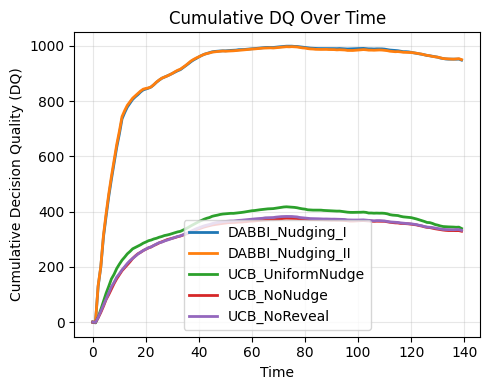

In [34]:
def load_cumulative_metrics(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    # Get cumulative DQ and nudges from metrics
    total_dq_cum = metrics.get('total_dq_cum', None)
    total_nudges_cum = metrics.get('total_nudges_cum', None)
    
    if total_dq_cum is None or total_nudges_cum is None:
        raise ValueError(f"Missing cumulative data in {metrics_path}")
    
    return np.array(total_dq_cum), np.array(total_nudges_cum)
def aggregate_cumulative_seed_level(dq_cum, nudges_cum):
    """Aggregate cumulative trajectories at seed level (across users)"""
    # dq_cum, nudges_cum: [num_seeds, num_users, num_times]
    S, U, T = dq_cum.shape
    
    # Average across users for each seed -> [num_seeds, num_times]
    dq_seed_mean = dq_cum.mean(axis=1)
    nudges_seed_mean = nudges_cum.mean(axis=1)
    
    # Mean across seeds -> [num_times]
    mean_dq = dq_seed_mean.mean(axis=0)
    mean_nudges = nudges_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = dq_seed_mean.shape[0]

    std_dq = dq_seed_mean.std(axis=0, ddof=1)
    std_nudges = nudges_seed_mean.std(axis=0, ddof=1)
    sem_dq = std_dq / np.sqrt(num_seeds)
    sem_nudges = std_nudges / np.sqrt(num_seeds)
    
    # 95% CI
    ci_dq = 1.96 * sem_dq
    ci_nudges = 1.96 * sem_nudges

    
    return mean_dq, mean_nudges, ci_dq, ci_nudges
def plot_cumulative_dq_vs_time(alg_data):
    """Plots Cumulative DQ versus Time steps."""
    plt.figure(figsize=(5, 4))
    
    for alg_name, (mean_dq, mean_nudges, ci_dq, ci_nudges) in alg_data.items():
        # *** KEY CHANGE: X-axis is time (index) ***
        t = np.arange(len(mean_dq)) 
        
        # Plot mean trajectory
        plt.plot(t, mean_dq, label=alg_name, linewidth=2)
        
        # Add confidence bands (using DQ uncertainty)
        # plt.fill_between(t, 
        #                 mean_dq - ci_dq, 
        #                 mean_dq + ci_dq, 
        #                 alpha=0.2)
    
    plt.xlabel('Time') # Updated X-label
    plt.ylabel('Cumulative Decision Quality (DQ)')
    plt.title('Cumulative DQ Over Time') # Updated Title
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution for Cumulative DQ vs Time
if __name__ == '__main__':
    # We reuse the global 'algorithms' list defined near the top.
    
    dq_alg_data = {}
    for alg in algorithms:
        metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
        
        print(f"Processing Cumulative DQ vs Time for {alg}...")
        dq_cum, nudges_cum = load_cumulative_metrics(metrics_path)
        mean_dq, mean_nudges, ci_dq, ci_nudges = aggregate_cumulative_seed_level(dq_cum, nudges_cum)
        dq_alg_data[alg] = (mean_dq, mean_nudges, ci_dq, ci_nudges)

    plot_cumulative_dq_vs_time(dq_alg_data)

Processing Average DQ vs Time for DABBI_Nudging_I...
Processing Average DQ vs Time for DABBI_Nudging_II...
Processing Average DQ vs Time for UCB_UniformNudge...
Processing Average DQ vs Time for UCB_NoNudge...
Processing Average DQ vs Time for UCB_NoReveal...
Processing Average DQ vs Time for UCB_NoNudge...


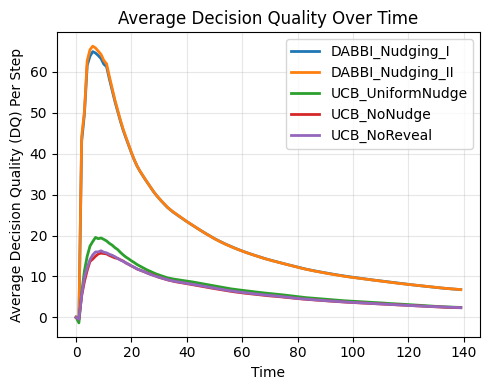

In [35]:
def aggregate_average_dq_seed_level(dq_cum, nudges_cum):
    """Aggregate AVERAGE DQ per step trajectories at seed level (across users)"""
    # dq_cum, nudges_cum: [num_seeds, num_users, num_times]
    S, U, T = dq_cum.shape
    
    # --- KEY CHANGE: Normalize Cumulative DQ by time step (t) to get the running average ---
    time_steps = np.arange(1, T + 1)
    # Broadcasting handles the division across all seeds and users
    average_dq_tensor = dq_cum / time_steps
    # --------------------------------------------------------------------------------------
    
    # Average across users for each seed -> [num_seeds, num_times]
    dq_seed_mean = average_dq_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_times]
    mean_avg_dq = dq_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = dq_seed_mean.shape[0]

    if num_seeds > 1:
        std_avg_dq = dq_seed_mean.std(axis=0, ddof=1)
        sem_avg_dq = std_avg_dq / np.sqrt(num_seeds)
        ci_avg_dq = 1.96 * sem_avg_dq
    else:
        ci_avg_dq = np.zeros_like(mean_avg_dq)
    
    # We return the mean cumulative nudges and its CI, though only mean_avg_dq and ci_avg_dq are used.
    # Note: Cumulative nudges are aggregated as before for consistency in the return signature.
    nudges_cum_mean = nudges_cum.mean(axis=1) 
    mean_nudges = nudges_cum_mean.mean(axis=0)
    std_nudges = nudges_cum_mean.std(axis=0, ddof=1) if num_seeds > 1 else np.zeros_like(mean_avg_dq)
    ci_nudges = 1.96 * (std_nudges / np.sqrt(num_seeds)) if num_seeds > 1 else np.zeros_like(mean_avg_dq)

    return mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges


# --- Plotting Function (Updated Title and Y-Label) ---

def plot_average_dq_vs_time(alg_data):
    """Plots Average DQ per Step versus Time steps."""
    plt.figure(figsize=(5, 4))
    
    # Note: We unpack the first and third returned values (mean_avg_dq, ci_avg_dq)
    for alg_name, (mean_avg_dq, _, ci_avg_dq, _) in alg_data.items():
        t = np.arange(len(mean_avg_dq)) 
        
        # Plot mean trajectory
        plt.plot(t, mean_avg_dq, label=alg_name, linewidth=2)
        
        # Add confidence bands (using DQ uncertainty)
        # plt.fill_between(t, 
        #                 mean_avg_dq - ci_avg_dq, 
        #                 mean_avg_dq + ci_avg_dq, 
        #                 alpha=0.2)
    
    plt.xlabel('Time')
    plt.ylabel('Average Decision Quality (DQ) Per Step') # <-- UPDATED LABEL
    plt.title('Average Decision Quality Over Time') # <-- UPDATED TITLE
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- Main Execution (Updated to call new aggregation and plotting functions) ---

if __name__ == '__main__':
    
    dq_alg_data = {}
    for alg in algorithms:
        metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
        
        print(f"Processing Average DQ vs Time for {alg}...")
        dq_cum, nudges_cum = load_cumulative_metrics(metrics_path)
        
        # *** KEY CHANGE: Calling the new Average DQ aggregation function ***
        mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges = aggregate_average_dq_seed_level(dq_cum, nudges_cum)
        dq_alg_data[alg] = (mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges)

    # *** KEY CHANGE: Calling the new Average DQ plotting function ***
    plot_average_dq_vs_time(dq_alg_data)

Processing DABBI_Nudging_I...
sem_average_quality: [2.23163225e-16 2.53103832e-03 3.78842185e-03 4.86418559e-03
 5.14377553e-03 5.23019574e-03 5.18967399e-03 5.23444754e-03
 5.20512544e-03 5.23042725e-03 5.21247121e-03 5.18396442e-03
 5.05517950e-03 4.95935216e-03 4.94658532e-03 4.89537108e-03
 4.85532430e-03 4.77333458e-03 4.70233737e-03 4.60527737e-03
 4.58939029e-03 4.53746084e-03 4.53633798e-03 4.47525343e-03
 4.36390396e-03 4.27038852e-03 4.18560763e-03 4.02963661e-03
 3.98966821e-03 3.89766189e-03 3.87304029e-03 3.82086196e-03
 3.82982669e-03 3.80545030e-03 3.81070039e-03 3.76265158e-03
 3.76227172e-03 3.71981411e-03 3.67158814e-03 3.58664637e-03
 3.54275580e-03 3.47173437e-03 3.47857573e-03 3.46179373e-03
 3.47099129e-03 3.44534762e-03 3.45874644e-03 3.44379581e-03
 3.45027650e-03 3.41566251e-03 3.41996885e-03 3.39454399e-03
 3.37263013e-03 3.32476004e-03 3.32745604e-03 3.29673657e-03
 3.30716612e-03 3.28958779e-03 3.30515001e-03 3.30682979e-03
 3.32043790e-03 3.30703980e-03 3.3

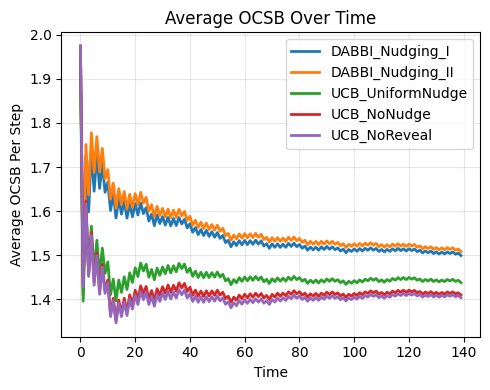

In [36]:
def load_quality_trajectories(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    quality_trajectories = metrics.get('quality_trajectories', None)
    if quality_trajectories is None:
        raise ValueError(f"Missing 'quality_trajectories' in {metrics_path}")
    
    return np.array(quality_trajectories)  # [num_seeds, num_users, num_times]
def aggregate_average_quality_seed_level(quality_tensor):
    """Aggregate average quality trajectories at seed level (across users)"""
    # quality_tensor: [num_seeds, num_users, num_times]
    S, U, T = quality_tensor.shape
    
    # Compute cumulative sum for each user trajectory
    cumulative_quality = np.cumsum(quality_tensor, axis=2)  # [S, U, T]
    
    # --- NEW STEP: Normalize by time step (t) to get the running average ---
    time_steps = np.arange(1, T + 1)
    # Broadcasting handles the division across all seeds and users
    average_quality_tensor = cumulative_quality / time_steps
    # -----------------------------------------------------------------------
    
    # Average across users for each seed -> [num_seeds, num_times]
    average_quality_seed_mean = average_quality_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_times]
    mean_average_quality = average_quality_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = average_quality_seed_mean.shape[0]
    if num_seeds > 1:
        std_average_quality = average_quality_seed_mean.std(axis=0, ddof=1)
        sem_average_quality = std_average_quality / np.sqrt(num_seeds)
        ci_average_quality = 1.96 * sem_average_quality
        print(f"sem_average_quality: {sem_average_quality}")
    else:
        ci_average_quality = np.zeros_like(mean_average_quality)
    
    return mean_average_quality, ci_average_quality


def plot_average_quality_trajectories(alg_data):
    plt.figure(figsize=(5, 4))
    
    for alg_name, (mean_avg_quality, ci_avg_quality) in alg_data.items():
        t = np.arange(len(mean_avg_quality))
        
        # Plot mean trajectory
        plt.plot(t, mean_avg_quality, label=alg_name, linewidth=2)
        
        # Add confidence bands
        # plt.fill_between(t, 
        #                 mean_avg_quality - ci_avg_quality, 
        #                 mean_avg_quality + ci_avg_quality, 
        #                 alpha=0.1)
    
    plt.xlabel('Time')
    plt.ylabel('Average OCSB Per Step') # <-- Updated Y-label
    plt.title('Average OCSB Over Time') # <-- Updated Title
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# Assuming algorithms, load_quality_trajectories, os, pickle, plt, and np are defined

# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    quality_tensor = load_quality_trajectories(metrics_path)
    
    # --- CHANGE: Use the new aggregation function ---
    mean_avg_quality, ci_avg_quality = aggregate_average_quality_seed_level(quality_tensor)
    alg_data[alg] = (mean_avg_quality, ci_avg_quality)

# --- CHANGE: Use the new plotting function ---
plot_average_quality_trajectories(alg_data)

In [37]:
def get_best_quality_user_indices(alg1_path, alg2_path, top_n=10):
    """
    Identifies indices of users where Alg1 (Primary) achieved the largest
    reduction in cumulative regret over Alg2 (Baseline).
    
    Gap = Cumulative Regret(Alg2) - Cumulative Regret(Alg1). 
    A larger positive gap means Alg1 is better.
    """
    # Load regret tensors
    r_tensor_1 = load_quality_trajectories(alg1_path) # DABBI_II
    r_tensor_2 = load_quality_trajectories(alg2_path) # UCB_UniformNudge
    
    if r_tensor_1.shape != r_tensor_2.shape:
        raise ValueError("Algorithm data shapes do not match! Cannot compare per-user.")
    
    # 1. Calculate final Cumulative Sums
    final_1 = np.cumsum(r_tensor_1, axis=2)[:, :, -1] # [num_seeds, num_users] (DABBI_II Regret)
    final_2 = np.cumsum(r_tensor_2, axis=2)[:, :, -1] # [num_seeds, num_users] (UCB_UniformNudge Regret)
    
    # 2. Average across seeds
    avg_final_1 = final_1.mean(axis=0) # [num_users]
    avg_final_2 = final_2.mean(axis=0) # [num_users]
    
    # 3. Calculate the Gap (Alg2 - Alg1). Positive = Alg1 is better (higher reward).
    reward_gap_scores = avg_final_1 - avg_final_2
    
    # 4. Get indices of the largest gaps (Top N)
    # argsort sorts low-to-high, so we take the last N and reverse
    sorted_indices = np.argsort(reward_gap_scores)
    best_reward_indices = sorted_indices[-top_n:][::-1]
        
    print(f"Top {top_n} Regret Gaps (UCB_UniformNudge Regret > DABBI_II Regret):")
    for i, idx in enumerate(best_reward_indices):
        print(f"User {idx}: Regret Gap = {reward_gap_scores[idx]:.2f}")
        
    return best_reward_indices




In [38]:
def load_regret_trajectories(metrics_path):
    with open(metrics_path, 'rb') as f:
        metrics = pickle.load(f)
    
    regret_trajectories = metrics.get('regret_trajectories', None)
    if regret_trajectories is None:
        raise ValueError(f"Missing 'regret_trajectories' in {metrics_path}")
    
    return np.array(regret_trajectories)  # [num_seeds, num_users, num_times]

def aggregate_cumulative_regret_seed_level(regret_tensor):
    """Aggregate cumulative regret trajectories at seed level (across users)"""
    # regret_tensor: [num_seeds, num_users, num_times]
    S, U, T = regret_tensor.shape
    
    # Compute cumulative sum for each user trajectory
    cumulative_regret = np.cumsum(regret_tensor, axis=2)  # [S, U, T]
    
    # Average across users for each seed -> [num_seeds, num_times]
    cumulative_regret_seed_mean = cumulative_regret.mean(axis=1)
    
    # Mean across seeds -> [num_times]
    mean_cumulative_regret = cumulative_regret_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = cumulative_regret_seed_mean.shape[0]
    if num_seeds > 1:
        std_cumulative_regret = cumulative_regret_seed_mean.std(axis=0, ddof=1)
        sem_cumulative_regret = std_cumulative_regret / np.sqrt(num_seeds)
        ci_cumulative_regret = 1.96 * sem_cumulative_regret
    else:
        ci_cumulative_regret = np.zeros_like(mean_cumulative_regret)
    
    return mean_cumulative_regret, ci_cumulative_regret

def plot_cumulative_regret_trajectories(alg_data):
    plt.figure(figsize=(5, 4))
    
    for alg_name, (mean_cum_regret, ci_cum_regret) in alg_data.items():
        t = np.arange(len(mean_cum_regret))
        
        # Plot mean trajectory
        plt.plot(t, mean_cum_regret, label=alg_name, linewidth=2)
        
        # Add confidence bands
        plt.fill_between(t, 
                        mean_cum_regret - ci_cum_regret, 
                        mean_cum_regret + ci_cum_regret, 
                        alpha=0.2)
    
    plt.xlabel('Time (decision steps)')
    plt.ylabel('Cumulative Regret')
    plt.title('Cumulative Regret Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Main execution
# alg_data = {}
# for alg in algorithms:
#     metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
#     if not os.path.exists(metrics_path):
#         print(f"Skipping {alg}: not found -> {metrics_path}")
#         continue
    
#     print(f"Processing {alg}...")
#     regret_tensor = load_regret_trajectories(metrics_path)
#     mean_cum_regret, ci_cum_regret = aggregate_cumulative_regret_seed_level(regret_tensor)
#     alg_data[alg] = (mean_cum_regret, ci_cum_regret)

# plot_cumulative_regret_trajectories(alg_data)


Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...
Processing UCB_NoReveal...
Processing UCB_NoNudge...


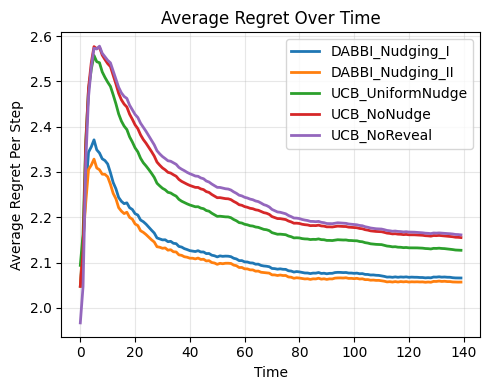

In [39]:
def aggregate_average_regret_seed_level(regret_tensor):
    """Aggregate average regret trajectories at seed level (across users)"""
    # regret_tensor: [num_seeds, num_users, num_times]
    S, U, T = regret_tensor.shape
    
    # Compute cumulative sum for each user trajectory
    cumulative_regret = np.cumsum(regret_tensor, axis=2)  # [S, U, T]
    
    # --- NEW STEP: Normalize by time step (t) to get the running average ---
    time_steps = np.arange(1, T + 1)
    # Broadcasting handles the division across all seeds and users
    average_regret_tensor = cumulative_regret / time_steps
    # -----------------------------------------------------------------------
    
    # Average across users for each seed -> [num_seeds, num_times]
    average_regret_seed_mean = average_regret_tensor.mean(axis=1)
    
    # Mean across seeds -> [num_times]
    mean_average_regret = average_regret_seed_mean.mean(axis=0)
    
    # SEM across seeds
    num_seeds = average_regret_seed_mean.shape[0]
    if num_seeds > 1:
        std_average_regret = average_regret_seed_mean.std(axis=0, ddof=1)
        sem_average_regret = std_average_regret / np.sqrt(num_seeds)
        ci_average_regret = 1.96 * sem_average_regret
    else:
        ci_average_regret = np.zeros_like(mean_average_regret)
    
    return mean_average_regret, ci_average_regret

def plot_average_regret_trajectories(alg_data):
    plt.figure(figsize=(5, 4))
    
    for alg_name, (mean_avg_regret, ci_avg_regret) in alg_data.items():
        t = np.arange(len(mean_avg_regret))
        
        # Plot mean trajectory
        plt.plot(t, mean_avg_regret, label=alg_name, linewidth=2)
        
        # Add confidence bands
        # plt.fill_between(t, 
        #                 mean_avg_regret - ci_avg_regret, 
        #                 mean_avg_regret + ci_avg_regret, 
        #                 alpha=0.2)
    
    plt.xlabel('Time')
    plt.ylabel('Average Regret Per Step') # <-- Updated Y-label
    plt.title('Average Regret Over Time') # <-- Updated Title
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
# Main execution
alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    # Use the existing loading function
    regret_tensor = load_regret_trajectories(metrics_path)
    
    # --- CHANGE: Use the new average aggregation function ---
    mean_avg_regret, ci_avg_regret = aggregate_average_regret_seed_level(regret_tensor)
    alg_data[alg] = (mean_avg_regret, ci_avg_regret)

# --- CHANGE: Use the new average plotting function ---
plot_average_regret_trajectories(alg_data)

Calculating lift: DABBI_Nudging_II vs DABBI_Nudging_I...
Top 10 Regret Gaps (UCB_UniformNudge Regret > DABBI_II Regret):
User 44: Regret Gap = 78.93
User 54: Regret Gap = 36.06
User 21: Regret Gap = 18.18
User 43: Regret Gap = 11.77
User 0: Regret Gap = 9.23
User 18: Regret Gap = 8.31
User 37: Regret Gap = 6.31
User 39: Regret Gap = 4.16
User 46: Regret Gap = 2.55
User 16: Regret Gap = 2.43
Processing DABBI_Nudging_I on high-lift users...
Processing DABBI_Nudging_II on high-lift users...
Processing UCB_UniformNudge on high-lift users...
Processing UCB_NoNudge on high-lift users...
Processing UCB_NoReveal on high-lift users...
Processing UCB_NoNudge on high-lift users...


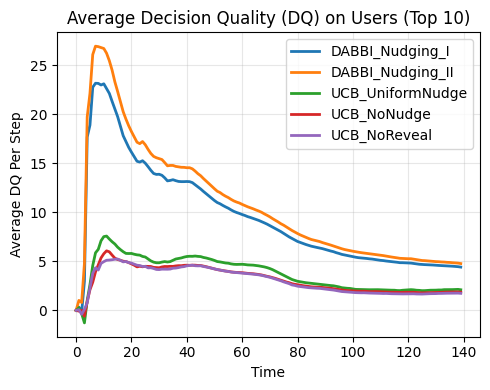

Processing DABBI_Nudging_I on high-lift users...
sem_average_quality: [1.95267822e-17 1.22893594e-02 2.27748225e-02 3.07020835e-02
 3.13198130e-02 3.17981181e-02 3.19910085e-02 3.21225655e-02
 3.19682473e-02 3.19461888e-02 3.19069017e-02 3.16236293e-02
 3.07124970e-02 3.02015390e-02 3.01549587e-02 2.99421170e-02
 2.96633838e-02 2.91169298e-02 2.86741295e-02 2.80102727e-02
 2.80993505e-02 2.78775201e-02 2.80792666e-02 2.76688169e-02
 2.69980857e-02 2.61493217e-02 2.56879160e-02 2.48243577e-02
 2.46646596e-02 2.40383505e-02 2.38520226e-02 2.34304982e-02
 2.33829046e-02 2.30709825e-02 2.31037174e-02 2.27975863e-02
 2.26929275e-02 2.23539288e-02 2.19902186e-02 2.14191310e-02
 2.11017290e-02 2.05942219e-02 2.06771087e-02 2.05965971e-02
 2.06203750e-02 2.04417791e-02 2.05317589e-02 2.04478863e-02
 2.04702572e-02 2.03094315e-02 2.04074308e-02 2.03174132e-02
 2.01764550e-02 1.98440782e-02 1.98326640e-02 1.95963337e-02
 1.96593651e-02 1.95262668e-02 1.96559233e-02 1.96112467e-02
 1.96622695e-02

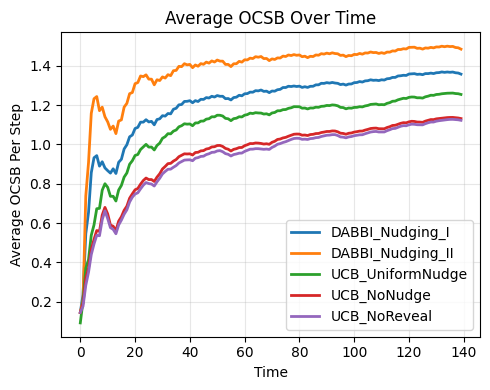

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...
Processing UCB_NoReveal...
Processing UCB_NoNudge...


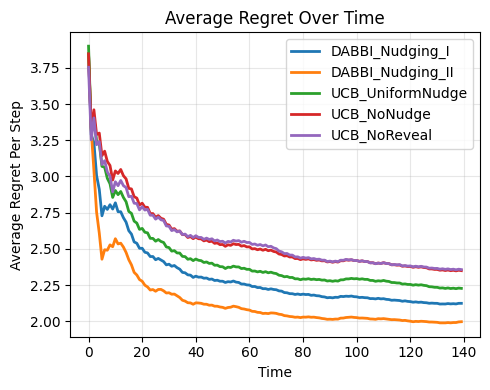

In [40]:
# Configuration for user selection
alg_primary = 'DABBI_Nudging_II'
alg_baseline = 'DABBI_Nudging_I'
algorithms_to_plot = algorithms
top_n_users = 10

# Paths
path_primary = os.path.join(base_dir, f'{alg_primary}_comprehensive_metrics.p')
path_baseline = os.path.join(base_dir, f'{alg_baseline}_comprehensive_metrics.p')

# 1. Calculate the Best Lift Indices (UNCHANGED)
if os.path.exists(path_primary) and os.path.exists(path_baseline):
    print(f"Calculating lift: {alg_primary} vs {alg_baseline}...")
    target_indices = get_best_quality_user_indices(path_primary, path_baseline, top_n=top_n_users)
else:
    raise FileNotFoundError("One or both algorithm files not found.")

def plot_average_dq_vs_time(alg_data):
    """Plots Average DQ per Step versus Time steps."""
    plt.figure(figsize=(5, 4))
    
    # Note: We unpack the first and third returned values (mean_avg_dq, ci_avg_dq)
    for alg_name, (mean_avg_dq, _, ci_avg_dq, _) in alg_data.items():
        t = np.arange(len(mean_avg_dq)) 
        
        # Plot mean trajectory
        plt.plot(t, mean_avg_dq, label=alg_name, linewidth=2)
        
        # Add confidence bands (using DQ uncertainty)
        # plt.fill_between(t, 
        #                 mean_avg_dq - ci_avg_dq, 
        #                 mean_avg_dq + ci_avg_dq, 
        #                 alpha=0.2)
    
    plt.xlabel('Time')
    plt.ylabel('Average DQ Per Step') # <-- UPDATED LABEL
    plt.title('Average Decision Quality (DQ) on Users (Top 10)') # <-- UPDATED TITLE
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
if __name__ == '__main__':
    
    dq_alg_data = {}
    for alg in algorithms:
        metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
        if not os.path.exists(metrics_path):
            print(f"Skipping {alg}: not found")
            continue
        
        print(f"Processing {alg} on high-lift users...")
        dq_cum, nudges_cum = load_cumulative_metrics(metrics_path)
        filter_dq_cum = dq_cum[:, target_indices, :]
        filter_nudges_cum = nudges_cum[:, target_indices, :]
        
        mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges = aggregate_average_dq_seed_level(filter_dq_cum, filter_nudges_cum)
        dq_alg_data[alg] = (mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges)

    plot_average_dq_vs_time(dq_alg_data)
    
alg_data = {}

for alg in algorithms_to_plot:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found")
        continue
    
    print(f"Processing {alg} on high-lift users...")
    
    full_quality = load_quality_trajectories(metrics_path)
    filtered_quality = full_quality[:, target_indices, :]
    
    # *** KEY CHANGE: Calling the average aggregation function ***
    mean_avg_quality, ci_avg_quality = aggregate_average_quality_seed_level(filtered_quality)
    alg_data[alg] = (mean_avg_quality, ci_avg_quality)

plot_average_quality_trajectories(alg_data)

# 3. Plotting (PLOTTING FUNCTION CHANGE)

alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    regret_tensor = load_regret_trajectories(metrics_path)
    filter_regret_tensor = regret_tensor[:, target_indices, :]
    mean_cum_regret, ci_cum_regret = aggregate_average_regret_seed_level(filter_regret_tensor)
    alg_data[alg] = (mean_cum_regret, ci_cum_regret)

plot_average_regret_trajectories(alg_data)


Calculating lift: DABBI_Nudging_II vs UCB_UniformNudge...
Top 10 Regret Gaps (UCB_UniformNudge Regret > DABBI_II Regret):
User 11: Regret Gap = 319.64
User 54: Regret Gap = 122.58
User 46: Regret Gap = 116.88
User 44: Regret Gap = 51.08
User 7: Regret Gap = 38.84
User 67: Regret Gap = 29.56
User 5: Regret Gap = 29.53
User 12: Regret Gap = 26.93
User 18: Regret Gap = 24.56
User 9: Regret Gap = 22.52
Processing DABBI_Nudging_I on high-lift users...
Processing DABBI_Nudging_II on high-lift users...
Processing UCB_UniformNudge on high-lift users...
Processing UCB_NoNudge on high-lift users...
Processing UCB_NoReveal on high-lift users...
Processing UCB_NoNudge on high-lift users...


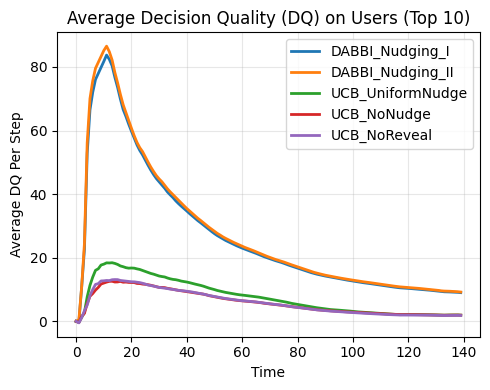

Processing DABBI_Nudging_I on high-lift users...
sem_average_quality: [0.         0.00564378 0.02136136 0.03024072 0.03150163 0.03263795
 0.03311687 0.03342663 0.03334648 0.03322235 0.03313986 0.03249266
 0.03158098 0.03073415 0.03038266 0.02984988 0.02936131 0.02865987
 0.02803085 0.02725143 0.02703379 0.02663342 0.02654259 0.02609062
 0.02547578 0.02487951 0.02447156 0.0237765  0.02350746 0.02301731
 0.02282441 0.02247577 0.02239169 0.02213118 0.02211745 0.02178935
 0.0216072  0.02125167 0.02093448 0.02047648 0.02024386 0.01993372
 0.02004157 0.02002599 0.02008071 0.01998206 0.02012771 0.02011913
 0.02017002 0.01999773 0.02006202 0.01998204 0.0198766  0.01964329
 0.01965725 0.01953613 0.01957862 0.01947787 0.01952855 0.01951762
 0.01954046 0.01941273 0.0195793  0.01962273 0.01978815 0.01973781
 0.01964737 0.01939143 0.01921446 0.01893201 0.0188911  0.01873002
 0.01869914 0.01858633 0.01858664 0.01852708 0.01858136 0.0184858
 0.01859094 0.01858518 0.01854935 0.01843026 0.01843361 0.01

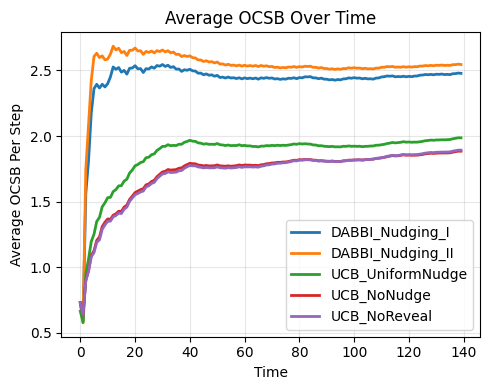

Processing DABBI_Nudging_I...
Processing DABBI_Nudging_II...
Processing UCB_UniformNudge...
Processing UCB_NoNudge...
Processing UCB_NoReveal...
Processing UCB_NoNudge...


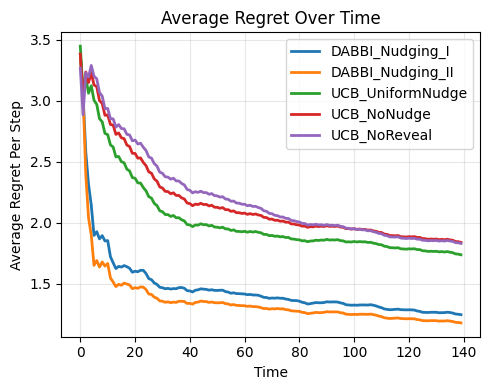

In [41]:
# Configuration for user selection
alg_primary = 'DABBI_Nudging_II'
alg_baseline = 'UCB_UniformNudge'
algorithms_to_plot = algorithms
top_n_users = 10

# Paths
path_primary = os.path.join(base_dir, f'{alg_primary}_comprehensive_metrics.p')
path_baseline = os.path.join(base_dir, f'{alg_baseline}_comprehensive_metrics.p')

# 1. Calculate the Best Lift Indices (UNCHANGED)
if os.path.exists(path_primary) and os.path.exists(path_baseline):
    print(f"Calculating lift: {alg_primary} vs {alg_baseline}...")
    target_indices = get_best_quality_user_indices(path_primary, path_baseline, top_n=top_n_users)
else:
    raise FileNotFoundError("One or both algorithm files not found.")

def plot_average_dq_vs_time(alg_data):
    """Plots Average DQ per Step versus Time steps."""
    plt.figure(figsize=(5, 4))
    
    # Note: We unpack the first and third returned values (mean_avg_dq, ci_avg_dq)
    for alg_name, (mean_avg_dq, _, ci_avg_dq, _) in alg_data.items():
        t = np.arange(len(mean_avg_dq)) 
        
        # Plot mean trajectory
        plt.plot(t, mean_avg_dq, label=alg_name, linewidth=2)
        
        # Add confidence bands (using DQ uncertainty)
        # plt.fill_between(t, 
        #                 mean_avg_dq - ci_avg_dq, 
        #                 mean_avg_dq + ci_avg_dq, 
        #                 alpha=0.2)
    
    plt.xlabel('Time')
    plt.ylabel('Average DQ Per Step') # <-- UPDATED LABEL
    plt.title('Average Decision Quality (DQ) on Users (Top 10)') # <-- UPDATED TITLE
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
if __name__ == '__main__':
    
    dq_alg_data = {}
    for alg in algorithms:
        metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
        if not os.path.exists(metrics_path):
            print(f"Skipping {alg}: not found")
            continue
        
        print(f"Processing {alg} on high-lift users...")
        dq_cum, nudges_cum = load_cumulative_metrics(metrics_path)
        filter_dq_cum = dq_cum[:, target_indices, :]
        filter_nudges_cum = nudges_cum[:, target_indices, :]
        
        mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges = aggregate_average_dq_seed_level(filter_dq_cum, filter_nudges_cum)
        dq_alg_data[alg] = (mean_avg_dq, mean_nudges, ci_avg_dq, ci_nudges)

    plot_average_dq_vs_time(dq_alg_data)
    
alg_data = {}

for alg in algorithms_to_plot:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found")
        continue
    
    print(f"Processing {alg} on high-lift users...")
    
    full_quality = load_quality_trajectories(metrics_path)
    filtered_quality = full_quality[:, target_indices, :]
    
    # *** KEY CHANGE: Calling the average aggregation function ***
    mean_avg_quality, ci_avg_quality = aggregate_average_quality_seed_level(filtered_quality)
    alg_data[alg] = (mean_avg_quality, ci_avg_quality)

plot_average_quality_trajectories(alg_data)

# 3. Plotting (PLOTTING FUNCTION CHANGE)

alg_data = {}
for alg in algorithms:
    metrics_path = os.path.join(base_dir, f'{alg}_comprehensive_metrics.p')
    if not os.path.exists(metrics_path):
        print(f"Skipping {alg}: not found -> {metrics_path}")
        continue
    
    print(f"Processing {alg}...")
    regret_tensor = load_regret_trajectories(metrics_path)
    filter_regret_tensor = regret_tensor[:, target_indices, :]
    mean_cum_regret, ci_cum_regret = aggregate_average_regret_seed_level(filter_regret_tensor)
    alg_data[alg] = (mean_cum_regret, ci_cum_regret)

plot_average_regret_trajectories(alg_data)
